In [1]:
from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics
import numpy as np

from matplotlib import pyplot as plt

import pandas as pd

import torch
from torch.nn import functional as F
from tqdm import tqdm

In [2]:
DEVICE = utils.get_device()

DEVICE

'cuda'

In [3]:
MODEL_NAME = "cifar100-resnet18-v1"
LAYER = "layer4"
SELECTED_CLASS = 50

In [4]:
dataset = datasets.construct("cifar100")

In [5]:
def get_train_of_class(class_ix=SELECTED_CLASS):
    ds_train = dataset.create_subset(train_split=True)
    targets = np.array(ds_train.targets)
    selected_indices = np.argwhere(targets == class_ix).reshape(-1)
    ds_train.data = ds_train.data[selected_indices]
    ds_train.targets = targets[selected_indices].tolist()
    print(f"We have {len(ds_train)} datapoints for Class {class_ix}")
    return ds_train
get_train_of_class(SELECTED_CLASS)

We have 500 datapoints for Class 50


Dataset CIFAR100
    Number of datapoints: 500
    Root location: /home/pchormai/projects/xai-kd/datasets/cifar100
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5070751592371323, 0.48654887331495095, 0.4409178433670343), std=(0.2673342858792401, 0.2564384629170883, 0.27615047132568404))
           )

In [6]:
ds_train = get_train_of_class()
dl_train = datasets.build_dataloader(ds_train, shuffle=False)
ds_val = dataset.create_subset(train_split=False)
dl_val = datasets.build_dataloader(ds_val, shuffle=False)

We have 500 datapoints for Class 50


In [7]:
model = models.get_trained_model(MODEL_NAME).to(DEVICE)

In [8]:
class SelectedClassEvicence(attributors.LogitModifier):
    def __init__(self, selected_class:int) -> None:
        self.selected_class = selected_class

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()

        one_hot = torch.zeros_like(logits)
        one_hot[:, self.selected_class] = 1
        one_hot = one_hot.to(logits.device)
        
        return logits * one_hot

In [9]:
logit_mod = SelectedClassEvicence(SELECTED_CLASS)

rng = np.random.default_rng(seed=1)

In [10]:
arr_act, arr_ctx = attributors.extract_activation_context(
    model=model,
    layer=LAYER,
    dataset=dataset,
    data_loader=dl_train,
    logit_modifier=logit_mod,
    rng=rng,
    device=DEVICE,
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:01<00:00,  4.16it/s]

layer4: output-dims=torch.Size([512, 4, 4])


In [11]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs


def estimate_basis(name):
    if name == "pca":
        return _solve_eigvecs(arr_act.T @ arr_act)
    elif name == "prca":
        return _solve_eigvecs(
            arr_act.T @ arr_ctx + arr_ctx.T @ arr_act ,
        )
        pass
    elif name == "prcaabs":
        return _solve_eigvecs(
            arr_act.T @ arr_ctx + arr_ctx.T @ arr_act ,
            sort_func=np.abs
        )
        pass
    else:
        raise

In [12]:
def ano():
    for basis_name in ["pca", "prca", "prcaabs"]:
        estimate_basis(basis_name)
    print("sanity check: passed!")
ano()

sanity check: passed!


In [13]:
from torchmetrics.classification import BinaryAUROC

In [14]:
def construct_fh(UUk):

    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            UUk
        ) 

    return fh

def estimate_auroc(model, dl):

    metric_auroc = BinaryAUROC()
    for x, y in dl:
        logit = model(x.to(DEVICE))[:, SELECTED_CLASS].cpu().detach()
        metric_auroc.update(
            logit,
            (y.detach() == SELECTED_CLASS)
        )
    auroc = metric_auroc.compute()
    if auroc < 0.5:
        auroc = 1-auroc
        
    return float(auroc)
        

@torch.no_grad()
def estimate_acc_at_k(basis_name, arr_ks):


    U = estimate_basis(basis_name)
    
    arr_rows = []

    for k in tqdm(arr_ks):
        Uk = U[:, :k]
        UUk = torch.from_numpy(Uk @ Uk.T).unsqueeze(2).unsqueeze(3).to(DEVICE)
        
        try:
            hook = getattr(model, LAYER).register_forward_hook(construct_fh(UUk))
            auroc = estimate_auroc(model, dl_val)
            
            arr_rows.append(dict(
                basis_name=basis_name, 
                k=k,
                auroc=auroc
            ))
        finally:
            hook.remove()


    return pd.DataFrame(arr_rows)

estimate_acc_at_k("pca", np.arange(0, 10, 2).tolist() + [256])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:09<00:00,  1.64s/it]


,basis_name,k,auroc
0,pca,0,0.500000
1,pca,2,0.970953
2,pca,4,0.969844
3,pca,6,0.965292
4,pca,8,0.966125
5,pca,256,0.959378


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:18<00:00,  1.65s/it]


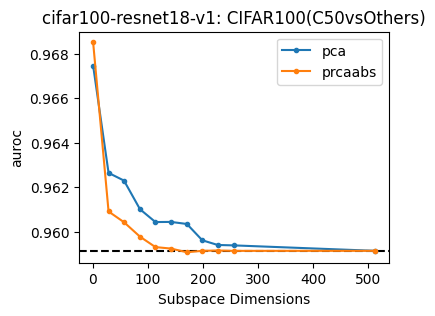

In [15]:
def viz():
    d = arr_act.shape[1]

    plt.figure(figsize=(4, 3))
    plt.title(f"{MODEL_NAME}: CIFAR100(C{SELECTED_CLASS}vsOthers)")
    
    arr_ks =  np.linspace(1, d//2, num=10).astype(int).tolist() + [d]
    for bix, basis_name in enumerate([
        "pca", 
        # "prca", 
        "prcaabs"
    ]):
        df = estimate_acc_at_k(basis_name, arr_ks)

        if bix == 0:
            plt.axhline(df["auroc"].values[-1], ls="--", color="k")

        if "unit" in basis_name:
            ls = ":"
            color= plt.gca().lines[-1].get_color()
        else:
            ls = "-"
            color = None
        plt.plot(
            df.k,
            df["auroc"],
            label=basis_name,
            color=color,
            ls=ls,
            marker="."
        )
    plt.xlabel("Subspace Dimensions")
    plt.ylabel("auroc")
    plt.legend()
viz()